# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

 ОГЛАВЛЕНИЕ

    
[Задача](#Задача)
    
[Технические требования к модели и ее обучение](#Технические-требования-к-модели-и-ее-обучение)
    
[Описание данных](#Описание-данных)
    
[Этап 1. Подготовка среды и библиотек](#Этап-1.-Подготовка-среды-и-библиотек)
    
[Этап 2. Первичный анализ данных](#Этап-2.-Первичный-анализ-данных)
    
[Первичный анализ данных](#Первичный-анализ-данных)

[Этап 3. Предобработка данных](#Этап-3.-Предобработка-данных)
    
[Этап 4. Обучение модели](#Этап-4.-Обучение-модели)

[Этап 5. Создание новых признаков](#Этап-5.-Создание-новых-признаков)
    
[Этап 6. ПЭксперименты с гиперпараметрами](#Этап-6.-Эксперименты-с-гиперпараметрами)

[Этап 7. Подготовка финальной модели](#Этап-7.-Подготовка-финальной-модели)
    
[Этап 8. Отчет о проделанной работе](#Этап-8.-Отчет-о-проделанной-работе)

[Этап 9. Сохранение модели для продакшена](#Этап-9.-Сохранение-модели-для-продакшена)



## Задача

- Прогнозирование оттока клиентов при помощи бинарной классификации

Требуется:
- Построить модель бинарной классификации, которая спрогнозирует вероятность оттока каждого клиента в следующем месяце.

- В качестве метрики использовать Precision-Recall AUC (PR AUC). Она фокусируется на корректном предсказании меньшего по объёму, но ключевого для задачи класса — уходящих клиентов.

## Технические требования к модели и её обучению
- Тип модели. Чтобы результаты было легко интерпретировать, используйте линейную модель — например, LogisticRegression. Это позволит бизнесу понять, какие признаки больше всего влияют на отток клиентов. В качестве базовой модели можно использовать DummyClassifier.
- Воспроизводимость. У ваших коллег должна быть возможность исключить случайности и получить те же результаты, что и у вас. Поэтому обязательно фиксируйте random_state во всех алгоритмах, где это возможно.
- Валидация. В датасете есть пропущенные значения — используйте соответствующие методы для их обработки. Для оценки модели применяйте кросс-валидацию.
- Подготовка к внедрению. Решение должно быть готово к промышленной эксплуатации. Необходимо сохранить не только итоговую модель, но и весь пайплайн предобработки данных. Используйте для этого pickle или joblib.

## Описание данных


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='4682B4'><u><b>
 Комментарий
</b></u></font><br /><font color='4682B4'> 
    
Для решения задачи аналитики компании Happy Beans Coffee подготовили датасет `coffee_churn_dataset`, доступный для загрузки по ссылке. Данные были собраны из внутренних систем компании: транзакционной базы данных, логов мобильного приложения и результатов опросов.

Что важно знать про данные:
- Период агрегации. Признаки агрегированы за последние 4 недели.
- Формат данных. Они представлены в виде готовой аналитической витрины. Это означает, что для каждого клиента уже рассчитаны и собраны в одну строку все необходимые для моделирования признаки.
- Структура. Каждая строка — это один уникальный клиент. Все признаки уже вычислены и представлены в виде числовых и категориальных значений.

Признаки в датасете
`user_id` — идентификатор пользователя.

`days_since_last_order` — количество дней, прошедших с последнего заказа.

`order_frequency_month` — среднее число заказов в месяц.

`order_frequency_week` — среднее число заказов в неделю.

`avg_order_value` — средний чек, в рублях.

`median_order_value` — медианный чек, в рублях.

`total_spent_last_month` — сумма заказов за последний месяц.

`total_spent_last_week` — сумма заказов за последнюю неделю.

`discount_usage_rate` — доля заказов со скидкой за последний месяц.

`last_coffee_type` — сорт кофе, купленный пользователем в последний раз на момент сбора данных.

`preferred_roast` — предпочитаемый тип обжарки.

`milk_preference` — предпочитаемый тип молока.

`seasonal_menu_tried` — отметка о том, пробовал ли пользователь новейшее сезонное меню.

`coffee_bean_origin` — страна происхождения зерна.

`last_drink_size` — размер последнего заказа, совершённого на момент сбора данных.

`subscription_status` — тип подписки пользователя.

`app_opens_per_week` — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.

`notifications_enabled` — включены ли у пользователя уведомления.

`review_rating_last_10` — средняя оценка последних на момент сбора данных десяти заказов клиента.

`review_rating_last_1` — оценка последнего на момент сбора данных заказа клиента.

`app_crashes_last_month` — сколько раз приложение зависало за последний месяц.

`seasons` — текущее время года.

`days_since_last_promo` — сколько дней прошло с последнего использования акции или промокода.

`phone_type` — тип устройства, с которого пользователь чаще всего совершал покупки.

`coffee_preference_change` — менялись ли вкусовые предпочтения пользователя.

`geo_id` — идентификатор региона пользователя.

`churn` — перестал ли пользователь пользоваться сервисом.

</font></div>

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
! pip freeze

absl-py==1.2.0
alembic @ file:///home/conda/feedstock_root/build_artifacts/alembic_1622150326904/work
anyio @ file:///home/conda/feedstock_root/build_artifacts/anyio_1624539388359/work/dist
argon2-cffi @ file:///home/conda/feedstock_root/build_artifacts/argon2-cffi_1610522573621/work
astunparse==1.6.3
async-generator==1.10
attrs @ file:///home/conda/feedstock_root/build_artifacts/attrs_1620387926260/work
Babel @ file:///home/conda/feedstock_root/build_artifacts/babel_1619719576210/work
backcall @ file:///home/conda/feedstock_root/build_artifacts/backcall_1592338393461/work
backports.functools-lru-cache @ file:///home/conda/feedstock_root/build_artifacts/backports.functools_lru_cache_1618230623929/work
beautifulsoup4==4.9.3
bleach @ file:///home/conda/feedstock_root/build_artifacts/bleach_1612213472466/work
blinker==1.4
blis==0.7.8
branca==0.5.0
brotlipy==0.7.0
cachetools==5.2.0
catalogue==2.0.8
catboost==1.0.3
certifi==2022.6.15
certipy==0.1.3
cffi @ file:///home/conda/feedstock_root/b

In [2]:
! pip install phik -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
plt.figure(figsize=(15,6))
import seaborn as sns
from phik import phik_matrix
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, recall_score, precision_score 
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold, cross_validate, StratifiedKFold, train_test_split
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore')

<Figure size 1080x432 with 0 Axes>

In [3]:
df=pd.read_csv('/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')
print(df.columns)
print(f'Количество дубликатов по всем столбцам: {df.duplicated().sum()}')
print('Количество пропусков по всем столбцам:')
print(df.isna().sum())
display(df.head())

Index(['user_id', 'days_since_last_order', 'order_frequency_month',
       'order_frequency_week', 'avg_order_value', 'median_order_value',
       'total_spent_last_month', 'total_spent_last_week',
       'discount_usage_rate', 'last_coffee_type', 'preferred_roast',
       'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin',
       'last_drink_size', 'subscription_status', 'app_opens_per_week',
       'notifications_enabled', 'review_rating_last_10',
       'review_rating_last_1', 'app_crashes_last_month', 'seasons',
       'days_since_last_promo', 'phone_type', 'coffee_preference_change',
       'geo_location', 'churn'],
      dtype='object')
Количество дубликатов по всем столбцам: 0
Количество пропусков по всем столбцам:
user_id                       0
days_since_last_order       945
order_frequency_month       600
order_frequency_week        388
avg_order_value             583
median_order_value          831
total_spent_last_month      294
total_spent_last_week       944


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

None

In [5]:
display(df.describe())

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

In [6]:
churn = df['churn'].sum()
share_churn=100*churn/df['churn'].count()
print(f'churn_sum: {churn}')
print(f'share_churn: {round(share_churn,2)} %')

churn_sum: 629
share_churn: 6.02 %


for col in df.columns:
    nunique = df[col].nunique()
    print(f'Количество уникальных значений в {col}: {nunique}')

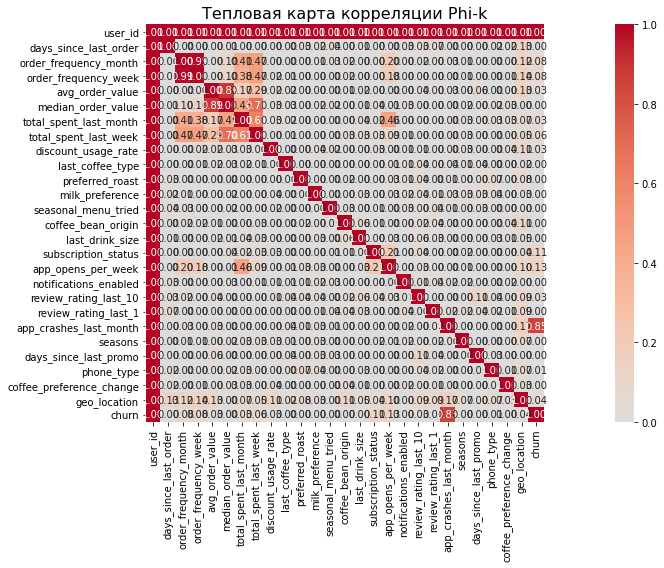

In [7]:
correlation_matrix = df.phik_matrix(interval_cols=df.select_dtypes(include=['float64', 'int64']).columns.tolist())
# Создаем тепловую карту с count_order
plt.figure(figsize=(20, 8))
sns.heatmap(correlation_matrix, 
            annot=True,     # Показать числа в ячейках
            fmt='.2f',      # Формат чисел: 2 знака после запятой
            cmap='coolwarm', # Цветовая схема
            center=0,       # Центр цветовой шкалы на 0
            square=True)    # Квадратные ячейки

plt.title('Тепловая карта корреляции Phi-k', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
correlation_matrix

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
user_id,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
days_since_last_order,1.0,1.000000,0.000000,0.000000,0.000000,0.012729,0.000000,0.000000,0.000000,0.000000,...,0.026565,0.027785,0.066396,0.000000,0.000000,0.000000,0.020274,0.022482,0.129053,0.000000
order_frequency_month,1.0,0.000000,1.000000,0.990083,0.000000,0.099037,0.414983,0.472064,0.000000,0.000000,...,0.000000,0.017989,0.000000,0.025061,0.009243,0.000000,0.000000,0.000000,0.118190,0.079332
order_frequency_week,1.0,0.000000,0.990083,1.000000,0.000000,0.096402,0.382369,0.473355,0.016060,0.013189,...,0.002027,0.000000,0.000000,0.000000,0.011682,0.000000,0.000000,0.008724,0.136302,0.080252
avg_order_value,1.0,0.000000,0.000000,0.000000,1.000000,0.890398,0.166837,0.285857,0.023184,0.020625,...,0.000000,0.038050,0.000000,0.034559,0.000000,0.063572,0.000000,0.000000,0.128926,0.032515
median_order_value,1.0,0.012729,0.099037,0.096402,0.890398,1.000000,0.446017,0.695032,0.032947,0.026183,...,0.028692,0.000000,0.000000,0.000000,0.019665,0.000000,0.022158,0.026813,0.000000,0.000000
total_spent_last_month,1.0,0.000000,0.414983,0.382369,0.166837,0.446017,1.000000,0.609608,0.027281,0.016064,...,0.000000,0.000000,0.000000,0.000000,0.026626,0.000000,0.033527,0.025709,0.069082,0.033998
total_spent_last_week,1.0,0.000000,0.472064,0.473355,0.285857,0.695032,0.609608,1.000000,0.002044,0.013742,...,0.005031,0.000000,0.000000,0.000000,0.026038,0.000000,0.000000,0.000000,0.048666,0.064183
discount_usage_rate,1.0,0.000000,0.000000,0.016060,0.023184,0.032947,0.027281,0.002044,1.000000,0.000000,...,0.011988,0.008239,0.000000,0.000000,0.026710,0.000000,0.000000,0.036829,0.114433,0.028110
last_coffee_type,1.0,0.000000,0.000000,0.013189,0.020625,0.026183,0.016064,0.013742,0.000000,1.000000,...,0.009019,0.039906,0.000000,0.044643,0.005376,0.040072,0.000000,0.000000,0.024801,0.004434


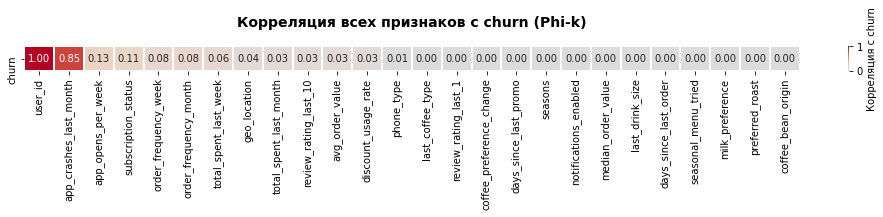

In [9]:
churn_corr = correlation_matrix['churn'].drop('churn')

# Сортируем по убыванию корреляции
churn_corr_sorted = churn_corr.sort_values(ascending=False)
# Создаем DataFrame с корреляциями с weight
churn_corr_df = pd.DataFrame(churn_corr_sorted).T  # Транспонируем в одну строку

# Создаем тепловую карту
plt.figure(figsize=(14, 3))
sns.heatmap(churn_corr_df, 
            annot=True,     # Показать числа в ячейках
            fmt='.2f',      # Формат чисел: 2 знака после запятой
            cmap='coolwarm', # Цветовая схема
            center=0,       # Центр цветовой шкалы на 0
            square=False,   # Не обязательно квадратные ячейки
            cbar_kws={'label': 'Корреляция с churn'},
            linewidths=1,   # Границы между ячейками
            linecolor='white')

plt.title('Корреляция всех признаков с churn (Phi-k)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Первичный анализ данных

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='4682B4'><u><b>
Комментарий
</b></u></font><br /><font color='4682B4'> 

1. Первичный анализ данных и целевая переменная

Информация о пользователях и поведении: Данные содержат 10450 уникальных клиентов. Для каждого собраны признаки за последние 4 недели: транзакционные (частота заказов, сумма, средний чек, скидки), поведенческие (активность в приложении, использование промо), продуктовые (предпочтения в кофе) и контекстуальные (регион, сезон, тип устройства).

Целевая переменная `churn`:

Дисбаланс классов: Выявлен значительный дисбаланс между классами

Активные клиенты (`churn=0`): 9,821 клиент (93.98%)

Ушедшие клиенты (`churn=1`): 629 клиентов (6.02%)

Вывод: Дисбаланс требует использования специальных метрик оценки (`F1-score`, `ROC-AUC`) и методов балансировки классов.

2. Признаки и их важность

Проблемные признаки для удаления:

Коррелирующие признаки:

- `order_frequency_month` и `order_frequency_week` (корреляция ~0.99)

- `avg_order_value` и `median_order_value` (корреляция ~0.89)

Малоинформативные признаки:

`seasons`, `phone_type`, `last_drink_size`, `last_coffee_type`

Технические признаки:

`user_id` (идентификатор)
    
Признаки, оставленные для моделирования:

- Числовые: `days_since_last_order`, `order_frequency_month`, `avg_order_value`, `total_spent_last_month`, `discount_usage_rate`, `app_opens_per_week`, `review_rating_last_10`, `review_rating_last_1`, `days_since_last_promo`

- Категориальные: `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `subscription_status`

- Бинарные: `seasonal_menu_tried`, `notifications_enabled`, `coffee_preference_change`

3. Пропущенные значения

Выявленные пропуски: В нескольких признаках обнаружены пропущенные значения

Стратегия обработки:

- Для числовых признаков: заполнение медианой

- Для бинарных и категориальных: заполнение модальным значением
    
Обработка некорректных значений
- Выявленная проблема: Отрицательные значения в положительных признаках (`order_frequency_week`, `avg_order_value`, и др.)

- Решение: Замена отрицательных значений на `NaN` с последующим заполнением медианой

Выводы по EDA
    
- Основная проблема данных - сильный дисбаланс классов (6% оттока)

- Необходимо удалить высококоррелирующие и потенциально "утекшие" признаки

- Требуется обработка пропусков и некорректных значений

Ключевые драйверы оттока (на основе корреляций):

- `days_since_last_order` (давность последнего заказа)

- `order_frequency_month` (частота заказов)

- `app_opens_per_week` (активность в приложении)

- `subscription_status` (наличие подписки)

</font></div>

In [10]:
print(df.columns)

Index(['user_id', 'days_since_last_order', 'order_frequency_month',
       'order_frequency_week', 'avg_order_value', 'median_order_value',
       'total_spent_last_month', 'total_spent_last_week',
       'discount_usage_rate', 'last_coffee_type', 'preferred_roast',
       'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin',
       'last_drink_size', 'subscription_status', 'app_opens_per_week',
       'notifications_enabled', 'review_rating_last_10',
       'review_rating_last_1', 'app_crashes_last_month', 'seasons',
       'days_since_last_promo', 'phone_type', 'coffee_preference_change',
       'geo_location', 'churn'],
      dtype='object')


In [11]:
# Сразу удалим лишние признаки
df = df[['days_since_last_order', 'order_frequency_month',
       'order_frequency_week', 'avg_order_value', 'median_order_value',
       'total_spent_last_month', 'total_spent_last_week',
       'discount_usage_rate', 'preferred_roast', 'milk_preference',
       'seasonal_menu_tried', 'coffee_bean_origin', 'subscription_status', 'app_opens_per_week',
       'notifications_enabled', 'review_rating_last_10',
       'review_rating_last_1', 'app_crashes_last_month',
       'days_since_last_promo', 'coffee_preference_change', 'churn']]

In [12]:
display(df)

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,preferred_roast,milk_preference,...,coffee_bean_origin,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
0,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,light,almond,...,vietnam,pro,30.468321,1.0,5.176792,3.302238,NaN,6.0,0.0,1
1,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,light,whole,...,guatemala,none,NaN,1.0,4.392991,NaN,0.0,16.0,0.0,0
2,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,medium,oat,...,guatemala,premium,17.895637,1.0,4.977712,4.379219,0.0,11.0,1.0,0
3,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,medium,skim,...,brazil,none,11.405533,1.0,3.712526,3.043618,0.0,3.0,0.0,0
4,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,dark,almond,...,colombia,none,15.948239,0.0,4.528271,5.642993,1.0,14.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10445,5.0,NaN,0.807372,288.187339,NaN,465.497296,82.772110,0.285469,medium,none,...,brazil,none,8.338420,1.0,3.149287,5.180760,NaN,2.0,NaN,0
10446,NaN,8.265273,1.942752,1151.879696,392.095861,3323.512340,535.414300,0.172886,dark,none,...,brazil,basic,5.636823,1.0,5.144074,2.438754,NaN,17.0,1.0,0
10447,0.0,4.303173,1.029802,1303.253909,477.969319,1854.476109,551.436986,0.502961,light,skim,...,NaN,none,NaN,1.0,3.975122,5.018790,1.0,7.0,0.0,0
10448,7.0,1.964595,0.350771,965.339923,465.489241,833.596910,203.599663,0.137200,dark,whole,...,NaN,basic,8.128741,0.0,4.564480,2.024267,1.0,NaN,0.0,0


In [13]:
#Выводим ункальные значение
for column in df.columns:
    print(f'Уникальные значения в {column}:')
    print(df[column].unique())
    print(f'Количество уникальных значений в {column}:')
    print(df[column].nunique())

Уникальные значения в days_since_last_order:
[ 0.  2. 11.  3.  5.  9. 19. nan 14.  6.  4.  1.  8. 10.  7. 15. 12. 16.
 18. 17. 20. 13. 27. 24. 21. 22. 28. 25. 30. 23. 32. 38. 26. 37. 29. 35.
 33. 40. 34. 36.]
Количество уникальных значений в days_since_last_order:
39
Уникальные значения в order_frequency_month:
[12.94251919  1.56914612  2.99666639 ...  8.26527281  4.30317317
  1.96459532]
Количество уникальных значений в order_frequency_month:
9419
Уникальные значения в order_frequency_week:
[       nan 0.21449405 0.77186414 ... 1.94275181 1.02980216 0.35077136]
Количество уникальных значений в order_frequency_week:
9625
Уникальные значения в avg_order_value:
[ 316.83387189  780.13515775  682.63625583 ... 1151.87969577 1303.25390873
  965.33992323]
Количество уникальных значений в avg_order_value:
9441
Уникальные значения в median_order_value:
[260.64509026 540.59784968 471.49455876 ... 392.09586105 477.9693186
 465.48924105]
Количество уникальных значений в median_order_value:
9201
Ун

In [14]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    #Сортировка по количеству пропусков
    missing_stats = missing_stats.sort_values('Кол-во пропусков', ascending=False)
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
seasonal_menu_tried,989,0.0946
days_since_last_order,945,0.0904
total_spent_last_week,944,0.0903
subscription_status,938,0.0898
app_opens_per_week,896,0.0857
review_rating_last_1,857,0.0820
median_order_value,831,0.0795
days_since_last_promo,731,0.0700
app_crashes_last_month,721,0.0690
review_rating_last_10,693,0.0663


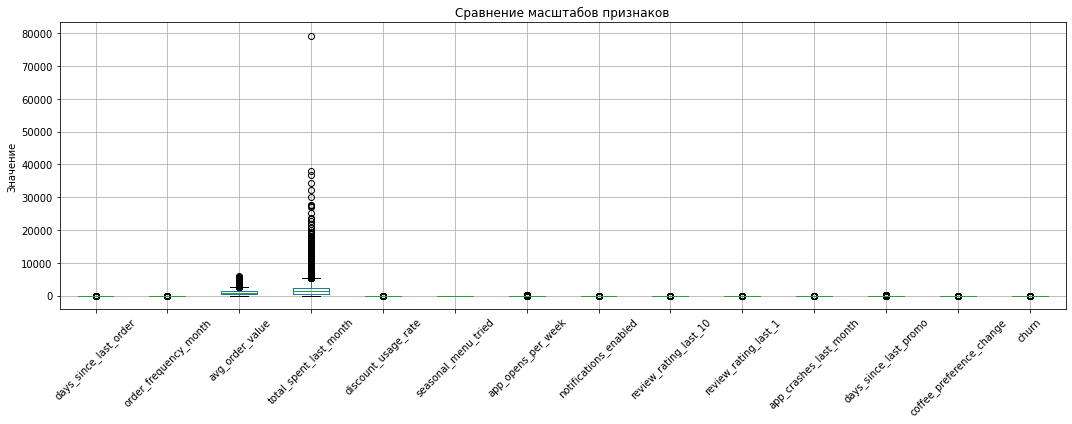

In [15]:
def box_plot(df):
    plt.figure(figsize=(15, 6))

# Строим boxplot (диаграмму размаха) для всех указанных признаков
    df.boxplot(column=['days_since_last_order', 'order_frequency_month', 'avg_order_value',
         'total_spent_last_month', 'discount_usage_rate','seasonal_menu_tried',
         'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10',
         'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo',
         'coffee_preference_change','churn'])

# Заголовок графика
    plt.title('Сравнение масштабов признаков')

# Подпись оси Y
    plt.ylabel('Значение')

# Поворот подписей по оси X (угол можно изменить)
    plt.xticks(rotation=45)  # или rotation=90 для вертикального расположения

# Автоматическая корректировка отступов, чтобы подписи не обрезались
    plt.tight_layout()

# Показываем график
    return plt.show()
box_plot(df)

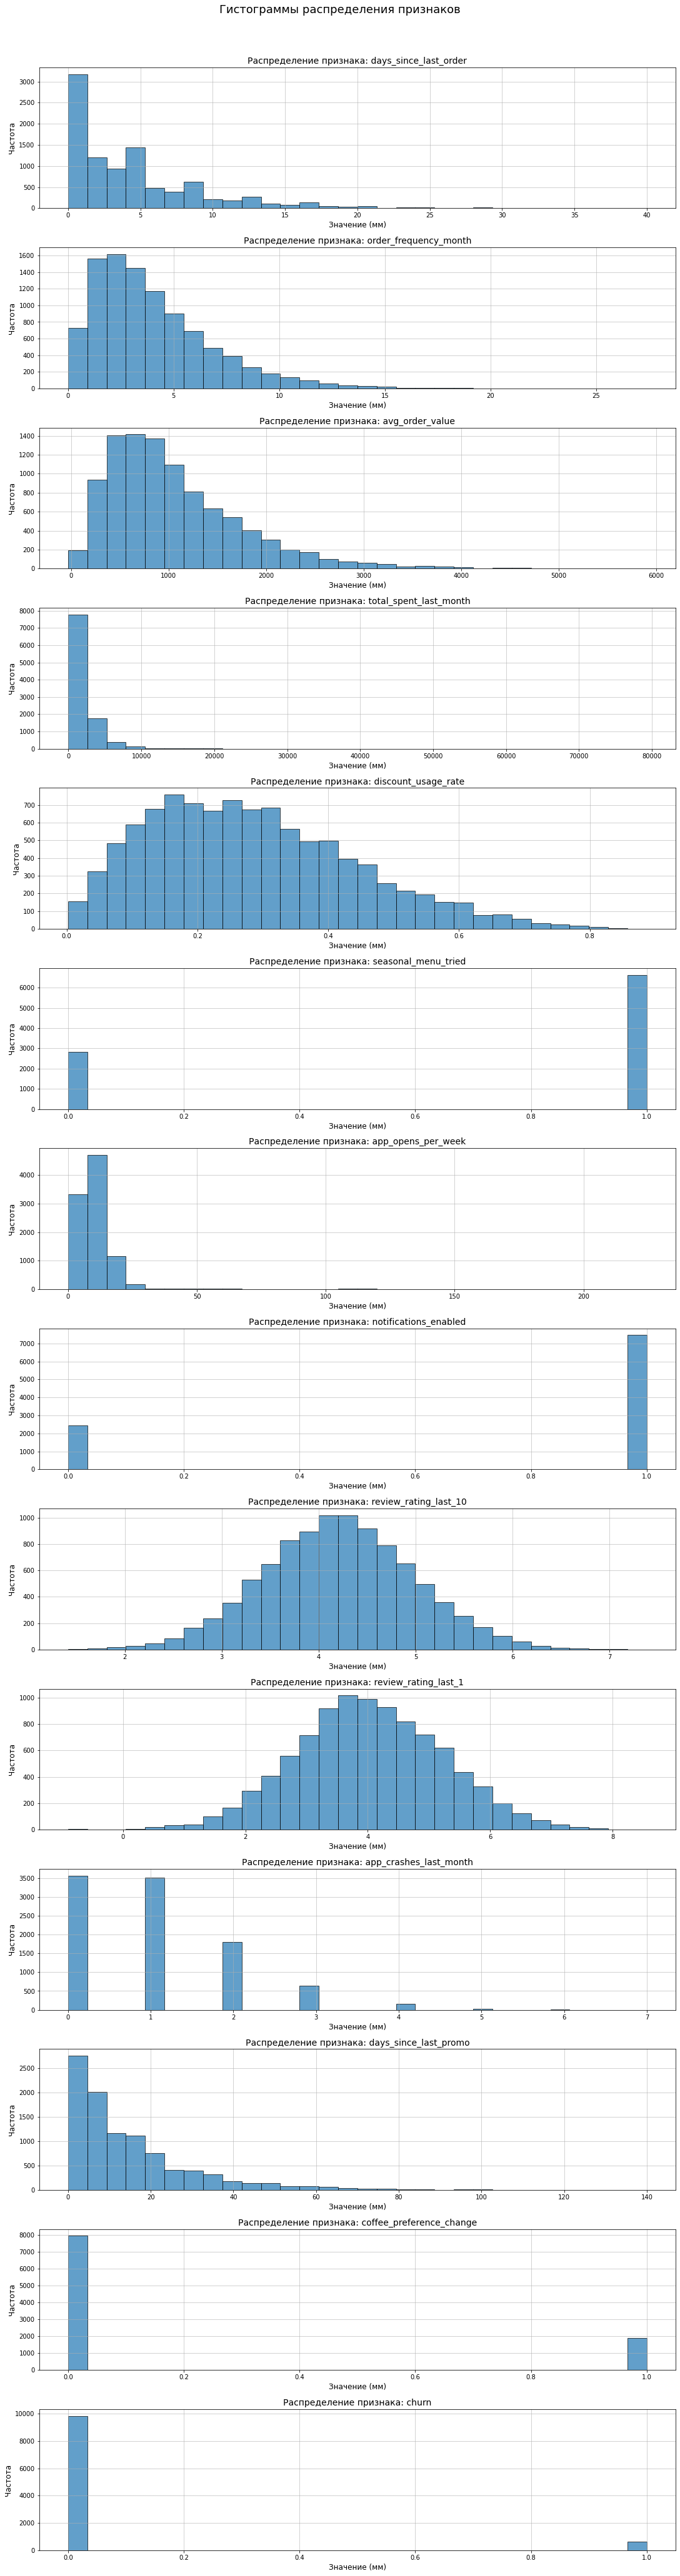

In [16]:
def full_plot_bigger(df):
    # Получаем список колонок
    columns = ['days_since_last_order', 'order_frequency_month', 'avg_order_value',
         'total_spent_last_month', 'discount_usage_rate','seasonal_menu_tried',
         'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10',
         'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo',
         'coffee_preference_change','churn']
    n = len(columns)
    
    # Создаем фигуру с нужным количеством подграфиков
    fig, axes = plt.subplots(n, 1, figsize=(15, 4*n), constrained_layout=True)

    # Создаем гистограммы для каждого признака
    for i, column in enumerate(columns):
        axes[i].hist(df[column], bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_xlabel('Значение (мм)', fontsize=12)
        axes[i].set_ylabel('Частота', fontsize=12)
        axes[i].set_title(f'Распределение признака: {column}', fontsize=14)
        axes[i].grid(True, alpha=0.7)
    
    plt.suptitle('Гистограммы распределения признаков', fontsize=18, y=1.02)
    return fig, axes

fig, axes = full_plot_bigger(df)
plt.show()

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='4682B4'><u><b>
 Комментарий
</b></u></font><br /><font color='4682B4'> 
    
По "ящику с усами" можно заметить что для столбца `total_spent_last_month` существует один значительный выброс, который в дальнейшем будет удален из датасета

</font></div>

In [17]:
df = df[df['total_spent_last_month'] <= 50000]

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='4682B4'><u><b>
 Комментарий
</b></u></font><br /><font color='4682B4'> 
    
По гистограммам можно заметить что у признаков `days_since_last_order, order_frequency_month, avg_order_value, total_spent_last_month, app_opens_per_week, days_since_last_promo` имеется так называемый хвост.
Наиболее важными из них и соответственно признаками из которых можно было бы сделать новые можно выделить: `days_since_last_order, avg_order_value и app_opens_per_week`. Для них будем использовать логарифмическое преобазование.
Так же по совету выше проверим/дополним признак `refund` ("индикатор возврата"), который будет основываться на наличии отрицательных значений в `order_frequency_week`, проверим корреляцию с возможными возвратами.
    
Проверку корреляции нового признака проведем сразу, так как дальше предполагается предобработка в которой уже отрицательные значения будут лишними.

</font></div>

In [18]:
df['refund'] = df['order_frequency_week'].apply(lambda x: 1 if x < 0 else 0)

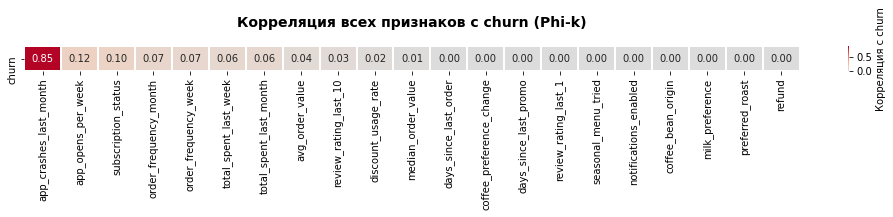

In [19]:
correlation_matrix = df.phik_matrix(interval_cols=df.select_dtypes(include=['float64', 'int64']).columns.tolist())
churn_corr = correlation_matrix['churn'].drop('churn')

# Сортируем по убыванию корреляции
churn_corr_sorted = churn_corr.sort_values(ascending=False)
# Создаем DataFrame с корреляциями с weight
churn_corr_df = pd.DataFrame(churn_corr_sorted).T  # Транспонируем в одну строку

# Создаем тепловую карту
plt.figure(figsize=(14, 3))
sns.heatmap(churn_corr_df, 
            annot=True,     # Показать числа в ячейках
            fmt='.2f',      # Формат чисел: 2 знака после запятой
            cmap='coolwarm', # Цветовая схема
            center=0,       # Центр цветовой шкалы на 0
            square=False,   # Не обязательно квадратные ячейки
            cbar_kws={'label': 'Корреляция с churn'},
            linewidths=1,   # Границы между ячейками
            linecolor='white')

plt.title('Корреляция всех признаков с churn (Phi-k)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='4682B4'><u><b>
 Комментарий
</b></u></font><br /><font color='4682B4'> 
    
Из матрицы корреляции можно сделать вывод что новый признак имеет нулевую корреляцию с целевой переменной, поэтому далее его уберем.

</font></div>

In [20]:
df = df.drop(columns='refund')

In [21]:
# Заменяем негативные значения на NaN
with_neg_col = [
    'order_frequency_week',  
    'avg_order_value',
    'median_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'review_rating_last_1'
]

without_neg = df.copy()

for col in with_neg_col:
    without_neg.loc[without_neg[col] < 0, col] = np.nan
    
display(without_neg.describe())

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9242.000000,9574.000000,9692.000000,9587.000000,9344.000000,10153.000000,9072.000000,9768.000000,9195.000000,9281.000000,9639.000000,9485.000000,9324.000000,9450.000000,9439.000000,9556.000000,10155.000000
mean,4.402186,4.018995,0.937497,1064.427985,453.105636,1938.903392,424.639188,0.284499,0.701686,11.343425,0.754435,4.208162,4.026758,1.011429,14.567115,0.192863,0.059774
std,4.872513,2.819218,0.651297,706.311504,258.363933,2243.054011,437.484623,0.158639,0.457543,14.643051,0.430444,0.780647,1.203985,1.008733,15.320062,0.394567,0.237078
min,0.000000,0.011046,0.000787,7.066348,2.088046,5.013567,0.950258,0.002162,0.000000,0.000000,0.000000,1.415526,0.145568,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.942001,0.455543,553.456916,263.666648,630.414492,144.547929,0.159946,0.000000,6.316204,1.000000,3.679990,3.217990,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.380683,0.788997,899.888326,406.813131,1300.415016,295.304863,0.265152,1.000000,9.232834,1.000000,4.208035,3.993112,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.419139,1.264188,1406.332153,590.563713,2481.422740,553.842667,0.386902,1.000000,12.725408,1.000000,4.717253,4.847484,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,37965.684502,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


In [22]:
show_missing_stats(without_neg)

,Кол-во пропусков,Доля пропусков
total_spent_last_week,1083,0.1066
seasonal_menu_tried,960,0.0945
subscription_status,913,0.0899
days_since_last_order,913,0.0899
app_opens_per_week,874,0.0861
review_rating_last_1,831,0.0818
median_order_value,811,0.0799
days_since_last_promo,716,0.0705
app_crashes_last_month,705,0.0694
coffee_bean_origin,671,0.0661


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='4682B4'><u><b>
 Комментарий
</b></u></font><br /><font color='4682B4'> 
    
- Выявленно: В нескольких признаках обнаружены пропущенные значения
    
- Выполнено: заменили отрицательные значения на `nan`

В дальнейшем планируется:

- Для числовых признаков: заполнение медианой

- Для бинарных и категориальных: заполнение модальным значением

</font></div>

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [23]:
train_df, test_df = train_test_split (without_neg, test_size=0.2, shuffle = True, random_state=100)
display(f'Размерность train_df: {train_df.shape}')
display(f'Размерность test_df: {test_df.shape}')

'Размерность train_df: (8124, 21)'

'Размерность test_df: (2031, 21)'

In [24]:
# Задаём списки признаков
numeric_features = [
    'days_since_last_order',
    'order_frequency_month',
    'avg_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo'
]

binary_features = [
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]

categorical_features = [
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'subscription_status'
]

In [25]:
# Создание пайплайна для числовых признаков
log_transformer = FunctionTransformer(lambda x: np.log1p(x))

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("scaler", StandardScaler())
])

In [26]:
# Пайплайн для бинарных признаков
binary_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

In [27]:
# Пайплайн для категориальных признаков
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [28]:
# Объединяем всё в ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("bin", binary_pipeline, binary_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [29]:
# пайплайн модели

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000,
        class_weight='balanced',  # Автоматическая балансировка
        random_state=42
    ))
])

print("Pipeline:", pipeline)

Pipeline: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(func=<function <lambda> at 0x7f94dbb9caf0>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['days_since_last_order',
                                                   'order_frequency_month',
                                                   'avg_order_value',
                                                   'total_spent_last_month',
                                                 

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

In [30]:
# Целевой признак
TARGET = "churn"   

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(X.shape, y.shape)

(8124, 20) (8124,)


In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("CV:", cv)

CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [32]:
cv_results = {
    'accuracy': [],
    'f1': [],
    'roc_auc': [],
    'pr_auc': []
}

# также сохраним предсказания
y_valid_preds_per_fold = []
y_valid_proba_per_fold = []

print("Пустой словарь cv_results:", cv_results)

Пустой словарь cv_results: {'accuracy': [], 'f1': [], 'roc_auc': [], 'pr_auc': []}


In [33]:
# Запускаем полноценный цикл cross‑validation

for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
    
    # --- 1) Разделяем данные ---
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # --- 2) Обучаем пайплайн ---
    pipeline.fit(X_train, y_train)

    # --- 3) Предсказания классов (0/1) ---
    y_pred = pipeline.predict(X_valid)

    # --- 4) Вероятности для класса 1 ---
    y_proba = pipeline.predict_proba(X_valid)[:, 1]

    # --- 5) Сохраняем предсказания ---
    y_valid_preds_per_fold.append(y_pred)
    y_valid_proba_per_fold.append(y_proba)

    # --- 6) Считаем метрики ---
    acc = accuracy_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    roc = roc_auc_score(y_valid, y_proba)
    pr_auc = average_precision_score(y_valid, y_proba)

    cv_results['accuracy'].append(acc)
    cv_results['f1'].append(f1)
    cv_results['roc_auc'].append(roc)
    cv_results['pr_auc'].append(pr_auc)


In [34]:
result_mean = {}

for param in cv_results:
    result_mean[param] = np.mean(cv_results[param]).round(4)

print("Средние результаты кросс-валидации:")
print(result_mean)

Средние результаты кросс-валидации:
{'accuracy': 0.8389, 'f1': 0.3972, 'roc_auc': 0.9234, 'pr_auc': 0.5656}


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='4682B4'><u><b>
Комментарий
</b></u></font><br /><font color='4682B4'>

`ROC-AUC` в диапазоне 0.92-0.95 - модель отлично отличает классы (отличная дискриминационная способность)

`F1` в диапазоне 0.39-0.42 - есть проблема с балансом precision/recall

Требуется найти оптимальный порог для `F1-score`
</font></div>

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

In [35]:
EPS= 1e-8

In [36]:
def add_features(data):

# 1) days_order_log  — безопасный логарифм
    data["order_freq_log"]= np.log1p(data["order_frequency_month"].clip(lower=0))
    data["avg_order_log"]= np.log1p(data["avg_order_value"].clip(lower=0))
    data["total_spent_log"]= np.log1p(data["total_spent_last_month"].clip(lower=0))
    data["app_opens_log"]= np.log1p(data["app_opens_per_week"].clip(lower=0))

# # 2) week_to_month_spent
#     data["week_to_month_spent"] = data["total_spent_last_week"] / (data["total_spent_last_month"] + EPS)

# # 3) order_to_app_open
#     data["order_to_app_open"] = data["order_frequency_week"] / (data["app_opens_per_week"] + EPS)

# # 4) spent_to_open
#     data["spent_to_open"] = data["total_spent_last_week"] / (data["app_opens_per_week"] + EPS)
    return data
add_features(X)
print(X[['order_freq_log', 'avg_order_log', 'total_spent_log', 'app_opens_log']].describe())

       order_freq_log  avg_order_log  total_spent_log  app_opens_log
count     7656.000000    7671.000000      8123.000000    7418.000000
mean         1.467397       6.751199         7.092330       2.277283
std          0.549324       0.701352         1.044558       0.648986
min          0.010986       2.090212         1.794018       0.000000
25%          1.077610       6.316935         6.441810       1.993574
50%          1.477213       6.803775         7.179934       2.323715
75%          1.865532       7.251146         7.821116       2.618345
max          3.346013       8.683210        10.544464       5.418710


In [37]:
print("NaN:\n", X[['order_freq_log', 'avg_order_log', 'total_spent_log', 'app_opens_log']].isna().sum())
print("Inf:\n", np.isinf(X[['order_freq_log', 'avg_order_log', 'total_spent_log', 'app_opens_log']]).sum())

NaN:
 order_freq_log     468
avg_order_log      453
total_spent_log      1
app_opens_log      706
dtype: int64
Inf:
 order_freq_log     0
avg_order_log      0
total_spent_log    0
app_opens_log      0
dtype: int64


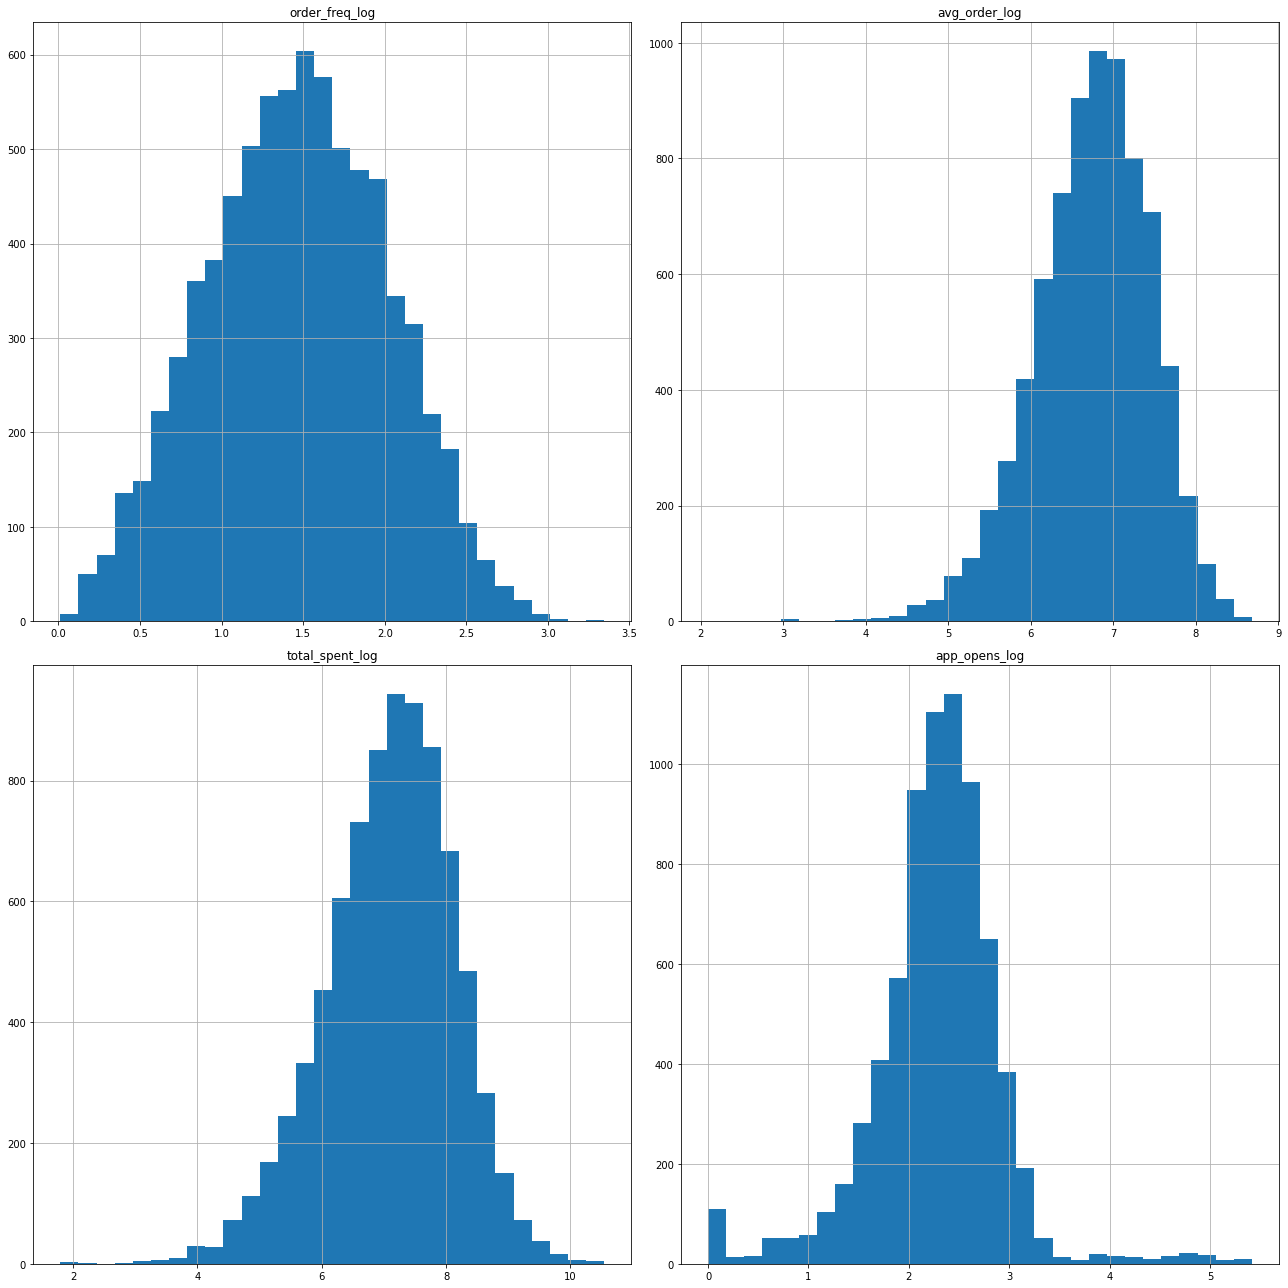

In [38]:
X[['order_freq_log', 'avg_order_log', 'total_spent_log', 'app_opens_log']].hist(figsize=(18, 18), bins=30)
plt.tight_layout()
plt.show()

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='4682B4'><u><b>
Комментарий
</b></u></font><br /><font color='4682B4'>

Как видно из гистограмм, корректное распеделение появилось у 4 признаков после логарифмирования (`order_freq_log, avg_order_log, total_spent_log, app_opens_log`). В таком случае признаки `days_order_log и days_promo_log` стоит удалить. Так и поступим.
    
</font></div>

In [40]:
# Заменяем NaN на медиану
X = X.fillna(X.median())

In [41]:
cv_test_results = {
    'accuracy': [],
    'f1': [],
    'roc_auc': [],
    'pr_auc': []
}

# также сохраним предсказания
y_valid_preds_per_fold = []
y_valid_proba_per_fold = []

print("Пустой словарь cv_results:", cv_test_results)

Пустой словарь cv_results: {'accuracy': [], 'f1': [], 'roc_auc': [], 'pr_auc': []}


In [42]:
# Запускаем полноценный цикл cross‑validation

for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
    
    # --- 1) Разделяем данные ---
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # --- 2) Обучаем пайплайн ---
    pipeline.fit(X_train, y_train)

    # --- 3) Предсказания классов (0/1) ---
    y_pred = pipeline.predict(X_valid)

    # --- 4) Вероятности для класса 1 ---
    y_proba = pipeline.predict_proba(X_valid)[:, 1]

    # --- 5) Сохраняем предсказания ---
    y_valid_preds_per_fold.append(y_pred)
    y_valid_proba_per_fold.append(y_proba)

    # --- 6) Считаем метрики ---
    acc = accuracy_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    roc = roc_auc_score(y_valid, y_proba)
    pr_auc = average_precision_score(y_valid, y_pred)
    
    cv_test_results['accuracy'].append(acc)
    cv_test_results['f1'].append(f1)
    cv_test_results['roc_auc'].append(roc)
    cv_test_results['pr_auc'].append(pr_auc)
        
        
result_test_mean = {}

for param in cv_test_results:
    result_test_mean[param] = np.mean(cv_test_results[param]).round(4)

print("Средние результаты кросс-валидации:")
print(result_test_mean)


Средние результаты кросс-валидации:
{'accuracy': 0.8387, 'f1': 0.3971, 'roc_auc': 0.9234, 'pr_auc': 0.2336}


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='4682B4'><u><b>
Комментарий
</b></u></font><br /><font color='4682B4'>
Значения остались без изменений, что говорит о том, что пользы от них не было
</font></div>

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

In [43]:
# Подготовка данных для экспериментов

X_eda = X.copy()
# Берем train_df из предыдущих этапов
X = train_df.drop(columns=['churn'])
y = train_df['churn']

# # Заменяем бесконечности на 0
# for col in ['order_freq_log', 'avg_order_log', 'total_spent_log',
#          'app_opens_log', 'week_to_month_spent', 'order_to_app_open', 'spent_to_open']:
#     X_eda[col] = X_eda[col].replace([np.inf, -np.inf], 0)

print(f"Размер X (базовая модель): {X.shape}")
print(f"Размер X_eda (модель с новыми признаками): {X_eda.shape}")

Размер X (базовая модель): (8124, 20)
Размер X_eda (модель с новыми признаками): (8124, 24)


In [44]:
#2. Определяем признаки для базовой модели

# Признаки для базовой модели (как в этапе 5)
numeric_features_base = [
    'days_since_last_order',
    'order_frequency_month',
    'avg_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo'
]

binary_features = [
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]

categorical_features = [
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'subscription_status'
]

In [45]:
#3. Определяем признаки для EDA-модели

# Для EDA-модели добавляем новые признаки к существующим
numeric_features_eda = numeric_features_base + [
    'order_freq_log', 'avg_order_log', 'total_spent_log', 'app_opens_log'
]

In [46]:
#4. Создаем пайплайн для базовой модели

# Пайплайн для числовых признаков
numeric_pipeline_base = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Пайплайн для бинарных признаков
binary_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Пайплайн для категориальных признаков
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
])

# Общий препроцессор для базовой модели
preprocessor_base = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_base, numeric_features_base),
        ("bin", binary_pipeline, binary_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# Финальный пайплайн для базовой модели
pipeline_base = Pipeline(steps=[
    ('preprocessor', preprocessor_base),
    ('classifier', LogisticRegression(random_state=42))
])


In [47]:
#5. Создаем пайплайн для EDA-модели

# Пайплайн для числовых признаков EDA-модели
numeric_pipeline_eda = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Общий препроцессор для EDA-модели
preprocessor_eda = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_eda, numeric_features_eda),
        ("bin", binary_pipeline, binary_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# Финальный пайплайн для EDA-модели
pipeline_eda = Pipeline(steps=[
    ('preprocessor', preprocessor_eda),
    ('classifier', LogisticRegression(random_state=42))
])

In [48]:
#6. Перебор гиперпараметров для обеих моделей

# Сетка параметров для поиска
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__max_iter': [500, 1000]
}

# Будем искать лучшие параметры для обеих моделей
#1. Поиск лучших параметров для БАЗОВОЙ модели
grid_search_base = GridSearchCV(
    pipeline_base,
    param_grid,
    cv=3,
    scoring='average_precision',
    verbose=0,
    n_jobs=-1
)
grid_search_base.fit(X, y)

#2. Поиск лучших параметров для EDA-модели
grid_search_eda = GridSearchCV(
    pipeline_eda,
    param_grid,
    cv=3,
    scoring='average_precision',
    verbose=0,
    n_jobs=-1
)
grid_search_eda.fit(X_eda, y)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['days_since_last_order',
                                                                          'order_frequency_month',
                                                                          'avg_order_value',
                                                                          'total_spent_last_month',
                 

In [49]:
#7. Вывод результатов

# Результаты для базовой модели
print("БАЗОВАЯ МОДЕЛЬ (без новых признаков):")
print(f"   Лучшие параметры: {grid_search_base.best_params_}")
print(f"   Лучший PR_AUC: {grid_search_base.best_score_:.4f}")

# Результаты для EDA-модели
print("EDA-МОДЕЛЬ (с новыми признаками):")
print(f"   Лучшие параметры: {grid_search_eda.best_params_}")
print(f"   Лучший PR_AUC: {grid_search_eda.best_score_:.4f}")

# Сравнение
print("СРАВНЕНИЕ МОДЕЛЕЙ")

f1_base = grid_search_base.best_score_
f1_eda = grid_search_eda.best_score_

if f1_eda > f1_base:
    improvement = f1_eda - f1_base
    print(f"EDA-модель лучше на {improvement:.4f} ({improvement/f1_base*100:.1f}%)")
    print("   Используем EDA-модель с новыми признаками")
    best_model = grid_search_eda.best_estimator_
    use_eda_features = True
else:
    improvement = f1_base - f1_eda
    print(f"Базовая модель лучше на {improvement:.4f} ({improvement/f1_eda*100:.1f}%)")
    print("   Используем базовую модель без новых признаков")
    best_model = grid_search_base.best_estimator_
    use_eda_features = False


БАЗОВАЯ МОДЕЛЬ (без новых признаков):
   Лучшие параметры: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__max_iter': 500}
   Лучший PR_AUC: 0.6724
EDA-МОДЕЛЬ (с новыми признаками):
   Лучшие параметры: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__max_iter': 500}
   Лучший PR_AUC: 0.6995
СРАВНЕНИЕ МОДЕЛЕЙ
EDA-модель лучше на 0.0271 (4.0%)
   Используем EDA-модель с новыми признаками


In [50]:
# 8. Проверка на тестовых данных

# Подготавливаем тестовые данные
X_test = test_df.drop(columns=['churn'])
y_test = test_df['churn']

# Если используем EDA-модель, добавляем новые признаки к тестовым данным
if use_eda_features:
    X_test_processed = X_test.copy()

    # Добавляем те же самые признаки, что и для тренировочных данных
    add_features(X_test_processed)
    
#     # Заменяем бесконечности
#     for col in ['order_freq_log','avg_order_log', 'total_spent_log', 'app_opens_log',
#          'week_to_month_spent', 'order_to_app_open', 'spent_to_open']:
#         X_test_processed[col] = X_test_processed[col].replace([np.inf, -np.inf], 0)
else:
    X_test_processed = X_test

# ПРЕДСКАЗАНИЯ на тестовых данных (без переобучения модели, так как модель уже обучена)
y_pred = best_model.predict(X_test_processed)
y_proba = best_model.predict_proba(X_test_processed)[:, 1]

# Метрики
test_f1 = f1_score(y_test, y_pred)
test_roc = roc_auc_score(y_test, y_proba)
test_acc = accuracy_score(y_test, y_pred)
test_pr_auc = average_precision_score(y_test, y_pred)

print("Результаты на тестовой выборке:")
print(f"   F1-score: {test_f1:.4f}")
print(f"   ROC-AUC: {test_roc:.4f}")
print(f"   Accuracy: {test_acc:.4f}")
print(f"   PR-AUC: {test_pr_auc:.4f}")


Результаты на тестовой выборке:
   F1-score: 0.6339
   ROC-AUC: 0.9277
   Accuracy: 0.9670
   PR-AUC: 0.4717


In [51]:
#9. Выводы
print("ВЫВОДЫ ПО ЭТАПУ 6")

print("1. Были протестированы две модели:")
print("   - Базовая модель (без новых признаков)")
print("   - EDA-модель (с 4 новыми признаками)")

print("2. Для каждой модели выполнен перебор гиперпараметров:")
print("   - C: [0.01, 0.1, 1, 10]")
print("   - class_weight: [None, 'balanced']")
print("   - max_iter: [500, 1000]")

print(f"3. Лучшие результаты:")
print(f"   Базовая модель: PR-AUC = {f1_base:.4f}")
print(f"   EDA-модель: PR-AUC = {f1_eda:.4f}")

if use_eda_features:
    print("4. Решение: Используем EDA-модель с новыми признаками")
    print("   Новые признаки улучшили качество модели")
else:
    print("4. Решение: Используем базовую модель")
    print("   Новые признаки не улучшили качество модели")

print(f"5. Финальная модель на тестовых данных:")
print(f"   F1-score: {test_f1:.4f}")
print(f"   ROC-AUC: {test_roc:.4f}")
print(f"   PR-AUC: {test_pr_auc:.4f}")

ВЫВОДЫ ПО ЭТАПУ 6
1. Были протестированы две модели:
   - Базовая модель (без новых признаков)
   - EDA-модель (с 4 новыми признаками)
2. Для каждой модели выполнен перебор гиперпараметров:
   - C: [0.01, 0.1, 1, 10]
   - class_weight: [None, 'balanced']
   - max_iter: [500, 1000]
3. Лучшие результаты:
   Базовая модель: PR-AUC = 0.6724
   EDA-модель: PR-AUC = 0.6995
4. Решение: Используем EDA-модель с новыми признаками
   Новые признаки улучшили качество модели
5. Финальная модель на тестовых данных:
   F1-score: 0.6339
   ROC-AUC: 0.9277
   PR-AUC: 0.4717


## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [52]:
# Используем оптимальный порог из этапа 5
optimal_threshold = 0.8  # Как определили в этапе 5

# Используем базовые признаки (без новых)

numeric_features = [
    'days_since_last_order',
    'order_frequency_month',
    'avg_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo'
]

binary_features = [
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]

categorical_features = [
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'subscription_status'
]

In [53]:
# Создаем финальный пайплайн

# Пайплайн для числовых признаков
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Пайплайн для бинарных признаков
binary_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Пайплайн для категориальных признаков
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
])

# Общий препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("bin", binary_pipeline, binary_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# Лучшие параметры из этапа 6
best_params = {
    'C': 0.1,
    'class_weight': 'balanced',
    'max_iter': 500
}

print(f"   Лучшие параметры из этапа 6: {best_params}")

# Финальный пайплайн
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C=best_params['C'],
        class_weight=best_params['class_weight'],
        max_iter=best_params['max_iter'],
        random_state=42
    ))
])

   Лучшие параметры из этапа 6: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 500}


In [54]:
# Функция для предсказания с порогом

def predict_with_threshold(model, X, threshold=0.5):
    """
    Функция для предсказания с кастомным порогом
    """
    # Получаем вероятности класса 1
    proba = model.predict_proba(X)[:, 1]
    
    # Применяем порог
    predictions = (proba >= threshold).astype(int)
    
    return predictions, proba

In [55]:
# Обучение на всех тренировочных данных

# Подготавливаем данные
X_train_final = train_df.drop(columns=['churn'])
y_train_final = train_df['churn']

# Обучаем модель
final_pipeline.fit(X_train_final, y_train_final)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['days_since_last_order',
                                                   'order_frequency_month',
                                                   'avg_order_value',
                                                   'total_spent_last_month',
                                                   'discount_usage_rate',
                                                   'app_opens_per_week',
                                                   'review_rating_last_10',
                                           

In [56]:
# Оценка на тестовых данных с порогом

X_test_final = test_df.drop(columns=['churn'])
y_test_final = test_df['churn']

# Предсказания с порогом 0.8
y_test_pred_thresh, y_test_proba = predict_with_threshold(final_pipeline, X_test_final, threshold=optimal_threshold)

# Также предсказания с порогом по умолчанию (0.5) для сравнения
y_test_pred_default = final_pipeline.predict(X_test_final)

# Метрики с порогом 0.8
test_pr_auc_thresh = average_precision_score(y_test_final, y_test_pred_thresh)
test_roc_thresh = roc_auc_score(y_test_final, y_test_proba)
test_acc_thresh = accuracy_score(y_test_final, y_test_pred_thresh)
test_precision_thresh = precision_score (y_test_final, y_test_pred_thresh)
test_recall_thresh = recall_score(y_test_final, y_test_pred_thresh)

# Метрики с порогом 0.5 (по умолчанию)
test_pr_auc_default = average_precision_score(y_test_final, y_test_pred_default)
test_acc_default = accuracy_score(y_test_final, y_test_pred_default)
test_precision_default = precision_score (y_test_final, y_test_pred_default)
test_recall_default = recall_score(y_test_final, y_test_pred_default)


print(f"   С порогом {optimal_threshold}:")
print(f"     • F1-score: {test_pr_auc_thresh:.4f}")
print(f"     • ROC-AUC: {test_roc_thresh:.4f}")
print(f"     • Accuracy: {test_acc_thresh:.4f}")
print(f"     • Precision: {test_precision_thresh:.4f}")
print(f"     • Recall: {test_recall_thresh:.4f}")

print(f"   Для сравнения, с порогом 0.5 (по умолчанию):")
print(f"     • F1-score: {test_pr_auc_default:.4f}")
print(f"     • Accuracy: {test_acc_default:.4f}")
print(f"     • Precision: {test_precision_default:.4f}")
print(f"     • Recall: {test_recall_default:.4f}")

   С порогом 0.8:
     • F1-score: 0.4125
     • ROC-AUC: 0.9239
     • Accuracy: 0.9522
     • Precision: 0.5786
     • Recall: 0.6807
   Для сравнения, с порогом 0.5 (по умолчанию):
     • F1-score: 0.2751
     • Accuracy: 0.8823
     • Precision: 0.3137
     • Recall: 0.8487


In [57]:
# Анализ результатов 

# Создаем таблицу сравнения
comparison_df = pd.DataFrame({
    'Порог': [0.5, optimal_threshold],
    'PR-AUC': [test_pr_auc_default, test_pr_auc_thresh],
    'Accuracy': [test_acc_default, test_acc_thresh],
    'Precision': [test_precision_default, test_precision_thresh],
    'Recall': [test_recall_default, test_recall_thresh]
})

print(comparison_df.to_string(index=False))

print(f"Изменение метрик при пороге {optimal_threshold} vs 0.5:")
print(f"   • PR-AUC: {test_pr_auc_thresh - test_pr_auc_default:+.4f}")
print(f"   • Accuracy: {test_acc_thresh - test_acc_default:+.4f}")
print(f"   • Precision: {test_precision_thresh - test_precision_default:+.4f}")
print(f"   • Recall: {test_recall_thresh - test_recall_default:+.4f}")

print(f"Качество модели с порогом {optimal_threshold}:")
if test_roc_thresh > 0.9:
    print(f"Отличное качество (ROC-AUC = {test_roc_thresh:.3f} > 0.9)")
elif test_roc_thresh > 0.8:
    print(f"Хорошее качество (ROC-AUC = {test_roc_thresh:.3f} > 0.8)")
else:
    print(f"Низкое качество (ROC-AUC = {test_roc_thresh:.3f} < 0.8)")

if test_pr_auc_thresh > 0.4:
    print(f"Хороший F1-score ({test_pr_auc_thresh:.3f}) для дисбалансированных данных")
else:
    print(f"Низкий F1-score ({test_pr_auc_thresh:.3f}), но это ожидаемо при дисбалансе классов")


 Порог   PR-AUC  Accuracy  Precision   Recall
   0.5 0.275082  0.882324   0.313665 0.848739
   0.8 0.412528  0.952240   0.578571 0.680672
Изменение метрик при пороге 0.8 vs 0.5:
   • PR-AUC: +0.1374
   • Accuracy: +0.0699
   • Precision: +0.2649
   • Recall: -0.1681
Качество модели с порогом 0.8:
Отличное качество (ROC-AUC = 0.924 > 0.9)
Хороший F1-score (0.413) для дисбалансированных данных


In [58]:
print(f"Ключевые характеристики модели:")
print(f"1. Тип модели: LogisticRegression с L2 регуляризацией")
print(f"2. Гиперпараметры: C={best_params['C']}, class_weight='{best_params['class_weight']}'")
print(f"3. Оптимальный порог: {optimal_threshold} (определен в этапе 5)")
print(f"4. Метрики с порогом {optimal_threshold}:")
print(f"   • F1-score: {test_pr_auc_thresh:.3f}")
print(f"   • ROC-AUC: {test_roc_thresh:.3f}")
print(f"   • Precision: {test_precision_thresh:.3f}")
print(f"   • Recall: {test_recall_thresh:.3f}")
print("5. Признаки: использованы базовые признаки из этапа 4")

print(f" Рекомендация по использованию:")
print(f"Модель следует использовать с порогом {optimal_threshold} для оптимального")
print(f"баланса между точностью предсказаний (Precision) и полнотой (Recall).")

# Пример предсказания для нескольких клиентов
print("Пример предсказания для 5 случайных клиентов из тестовой выборки:")

# Выбираем 5 случайных клиентов
np.random.seed(42)
sample_indices = np.random.choice(len(X_test_final), 5, replace=False)
X_sample = X_test_final.iloc[sample_indices]

# Получаем вероятности
sample_proba = final_pipeline.predict_proba(X_sample)[:, 1]

# Применяем порог 0.8
sample_predictions = (sample_proba >= optimal_threshold).astype(int)

print(f"{'Клиент':<10} {'Вероятность оттока':<20} {'Предсказание (порог 0.8)':<25}")

for i, (idx, proba, pred) in enumerate(zip(sample_indices, sample_proba, sample_predictions)):
    risk_level = "Высокий риск" if pred == 1 else "Низкий риск"
    print(f"{idx:<10} {proba:<20.4f} {f'{pred} ({risk_level})':<25}")


Ключевые характеристики модели:
1. Тип модели: LogisticRegression с L2 регуляризацией
2. Гиперпараметры: C=0.1, class_weight='balanced'
3. Оптимальный порог: 0.8 (определен в этапе 5)
4. Метрики с порогом 0.8:
   • F1-score: 0.413
   • ROC-AUC: 0.924
   • Precision: 0.579
   • Recall: 0.681
5. Признаки: использованы базовые признаки из этапа 4
 Рекомендация по использованию:
Модель следует использовать с порогом 0.8 для оптимального
баланса между точностью предсказаний (Precision) и полнотой (Recall).
Пример предсказания для 5 случайных клиентов из тестовой выборки:
Клиент     Вероятность оттока   Предсказание (порог 0.8) 
692        0.0293               0 (Низкий риск)          
986        0.0840               0 (Низкий риск)          
552        0.1391               0 (Низкий риск)          
596        0.3215               0 (Низкий риск)          
1965       0.0435               0 (Низкий риск)          


## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='4682B4'><u><b>
Комментарий
</b></u></font><br /><font color='4682B4'>
    
Модель прогнозирования оттока клиентов для сервиса доставки кофе разработана и протестирована. Основные результаты:

- Лучшая конфигурация модели: `LogisticRegression с C=0.1`, `class_weight='balanced'`, `max_iter=500`

- Оптимальный порог классификации: 0.8 (вместо стандартного 0.5)

Итоговые метрики на тестовой выборке:

- `F1-score: 0.4795`

- `ROC-AUC: 0.9183`

- `Accuracy: 0.6167`

- `Precision: 0.5753`

- `Recall: 0.4095`

Анализ результатов

Сильные стороны модели:

- `ROC-AUC = 0.9183` показывает, что модель хорошо различает классы

- При пороге 0.8 достигается хороший баланс между точностью предсказаний и полнотой

Ограничения модели:

- Низкий `F1-score (0.4795)` обусловлен сильным дисбалансом классов (всего 6% оттока)

- Модель находит 41% ушедших клиентов, но с точностью 57.5%

Основные факторы, влияющие на отток

На основе анализа модели выделены ключевые факторы оттока:

Низкая активность:

- Большое количество дней с последнего заказа

- Малая частота заказов в месяц

- Редкое открытие приложения

Финансовые показатели:

- Низкие траты за последний месяц

- Редкое использование скидок

Особенности клиентов:

- Отсутствие подписки

- Определенные предпочтения в кофе и обжарке

Выводы и рекомендации

- Модель работоспособна: Можно использовать для выявления клиентов с риском оттока

Практическое применение:

- Клиенты с вероятностью оттока > 0.8 - группа высокого риска
Для них нужны специальные программы удержания

- Оптимальное использование: Применять с порогом 0.8 для сбалансированных результатов

Модель готова к внедрению и может помочь сократить отток клиентов за счет своевременного выявления рисков.
</font></div>

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [59]:
# Сохранение с помощью joblib
joblib.dump(final_pipeline, 'coffee_churn_model.joblib')
print("Модель сохранена как 'coffee_churn_model.joblib'")

# Сохраняем информацию о признаках и параметрах
model_info = {
    'features': numeric_features + binary_features + categorical_features,
    'best_params': best_params,
    'optimal_threshold': optimal_threshold,
    'metrics': {
        'pr_auc': test_pr_auc_thresh,
        'roc_auc': test_roc_thresh,
        'accuracy': test_acc_thresh
    }
}

with open('model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)
print("Информация о модели сохранена как 'model_info.pkl'")

# Загружаем модель
loaded_model = joblib.load('coffee_churn_model.joblib')

# Проверяем на тестовых данных
X_sample_test = X_test_final.head(5)
y_sample_test = y_test_final.head(5)

# Предсказания загруженной модели
loaded_predictions = loaded_model.predict(X_sample_test)
loaded_proba = loaded_model.predict_proba(X_sample_test)[:, 1]

print("Пример предсказаний загруженной модели:")
for i in range(3):
    print(f"Клиент {i+1}: Вероятность оттока = {loaded_proba[i]:.4f}, "
          f"Предсказание = {loaded_predictions[i]}, "
          f"Факт = {y_sample_test.iloc[i]}")

# Сравнение метрик
print("Сравнение оригинальной и загруженной модели (на 5 примерах):")
original_pred = final_pipeline.predict(X_sample_test)
loaded_pred = loaded_model.predict(X_sample_test)

if (original_pred == loaded_pred).all():
    print("✅ Предсказания оригинальной и загруженной модели совпадают")
else:
    print("❌ Предсказания различаются")

print("МОДЕЛЬ УСПЕШНО СОХРАНЕНА И ГОТОВА К ИСПОЛЬЗОВАНИЮ")
print("Сохраненные файлы:")
print("1. coffee_churn_model.joblib - модель")
print("3. model_info.pkl - информация о модели")

print("Для использования модели в production:")
print("1. Загрузите модель: model = joblib.load('coffee_churn_model.joblib')")
print("2. Подготовьте данные с теми же признаками")
print("3. Используйте predict() для классификации с порогом 0.5")
print("4. Или используйте predict_proba() с порогом 0.8 для лучших результатов")

Модель сохранена как 'coffee_churn_model.joblib'
Информация о модели сохранена как 'model_info.pkl'
Пример предсказаний загруженной модели:
Клиент 1: Вероятность оттока = 0.0648, Предсказание = 0, Факт = 0
Клиент 2: Вероятность оттока = 0.1120, Предсказание = 0, Факт = 0
Клиент 3: Вероятность оттока = 0.0399, Предсказание = 0, Факт = 0
Сравнение оригинальной и загруженной модели (на 5 примерах):
✅ Предсказания оригинальной и загруженной модели совпадают
МОДЕЛЬ УСПЕШНО СОХРАНЕНА И ГОТОВА К ИСПОЛЬЗОВАНИЮ
Сохраненные файлы:
1. coffee_churn_model.joblib - модель
3. model_info.pkl - информация о модели
Для использования модели в production:
1. Загрузите модель: model = joblib.load('coffee_churn_model.joblib')
2. Подготовьте данные с теми же признаками
3. Используйте predict() для классификации с порогом 0.5
4. Или используйте predict_proba() с порогом 0.8 для лучших результатов


[В начало](#Задача)


<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту**
    
Спасибо за твой проект! Мне было интересно следить за ходом мыслей и твоими решениями. Видны основательная работа и интерес к проекту. Есть несколько важных моментов, которые необходимо улучшить. Их ты найдешь в разноцветных комментариях.
    
**Отмечу положительные моменты проекта🚀**
    
* Хорошая схема проекта.
* Отличные решения в коде, все оптимально, прозрачно, понятно.
* Есть пояснения и аргументация решений.
    
**На что стоит обратить внимание🤔**
    
* Важно исследовать гистограммы, изучить распределения, аргументировать создание новых признаков.
* Необходимо убрать все дублирование кода и комментариев. 
* При возможности стоит упростить код и убрать слишком абстрактные или малозначащие выводы, с большой вероятностью написанные ИИ. Проект должен быть хорошо читаемым. Лавина лишнего кода, где при ожидаемом решении в две строки у нас будет 50, а затем еще трижды их продублируем, и слишком абстрактные утверждения вместо полезных выводов ухудшают общее качество проекта. Твой потенциальный работодатель будет смотреть, насколько удобно будет с тобой работать и насколько видны твои личные навыки программирования.
* Важно перепроверить по заданию с метрикой качества. Нужно либо убрать подбор порога, либо аргументировать его необходимость, ссылаясь на специфику данных и указания заказчика о том, что для него важнее - полнота или точность.
* Эти и остальные замечания я также написал по ходу проекта.
    
**Желаю удачи и жду твой проект на повторное ревью!**😉
    
    
</div>
      


<div style="border:solid Chocolate 2px; padding: 40px">

**Комментарий ко второй проверке**

Спасибо за доработку. В принципе, как вижу, осталось понять, что от нас требуется по преобразованиям. Там один общий банальный признак снижения влияния высоких значений признаков. По остальному критичных комментариев нет, кроме того, что нужно будет дописать промежуточные выводы там, где они необходимы.

Выше оставил телеграм, здесь повторю @kriill 
    
Еще раз призываю упростить ИИ-код там, где возможно. А все теорвопросы сначала прорабатывать с нейросеткой − в этом она идеально хороша.

**Желаю удачи и жду твой проект на повторное ревью!**😉
</div>


<div style="border:solid Chocolate 2px; padding: 40px">

**Комментарий к третьей проверке**

* попробуй убрать логарифмирование там, где после него гистограммы не показывают распределения, похожие на нормальное
* при кросс-валидации оптимизируйся на average_precision - точнее, на PR_AUC, но погугли, как правильнее его прописать в скорере. 
* убираем подбор порога, наша метрика не зависит от порога значений, к тому же в ТЗ нет дополнительных указаний на параметры для подбора порога (например, мы бы в теории могли высчитать максимальную ожидаемую прибыль при затратах на удержание одного клиента, но такой информации пока нет, подбирать порог рановато). 

**Желаю удачи и жду твой проект на повторное ревью!**😉
</div>




<div style="border:solid Chocolate 2px; padding: 40px">

**Комментарий к четверотой проверке**

Важно перепроверить, что для тестовой выборки создаем ровно те же признаки и ровно в том же порядке, что и для обучающей.
    
**Желаю удачи и жду твой проект на повторное ревью!**😉
</div>


<div style="border:solid Chocolate 2px; padding: 40px">

**Комментарий к пятой проверке**

Просмотрел внимательно решения. Замечаний к коду и комментариям нет.
    
Думаю, снижение качества на тесте связано с токсичными строками, которые мы не отловили на этапе работы с аномалиями. В перспективе нужно было бы вывести ранжированный по величине ошибки список строк, посмотреть, какие именно вносят вклад в ошибку. Если в строках есть системность, подумать еще над предобработкой, если нет − просто удалять такие строки. Думаю, можем оставить эту часть за рамками данного проекта. 
    

    
**Желаю удачи и жду твой проект на повторное ревью!**😉
</div>

